<a href="https://colab.research.google.com/github/JosemCastano17/SyS-2025-ll/blob/main/Parcial_1_Se%C3%B1ales_y_Sistemas_Jose_Miguel_Casta%C3%B1o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcial 1 Señales y Sistemas
Jose Miguel Castaño Castaño

1193545283

jocastano@unal.edu.co

# Pregunta 1



##**Enunciado:**

Sean $x_1(t)=A\,e^{-j n\omega_0 t}$ y $x_2(t)=B\,e^{\,j m\omega_0 t}$, con $\omega_0=\dfrac{2\pi}{T}$ y $n,m\in\mathbb{Z}$. Se pide la distancia media entre $x_1$ y $x_2$:
$$
d^2(x_1,x_2)=\frac{1}{T}\int_{0}^{T}\big|x_1(t)-x_2(t)\big|^2\,dt.
$$


##**Desarrollo:**

Expansión del módulo y promedio en un período:

$$
\begin{aligned}
\big|x_1-x_2\big|^2
&=(x_1-x_2)(x_1-x_2)^*\\
&=x_1x_1^*+x_2x_2^*-x_1x_2^*-x_2x_1^*,
\end{aligned}
$$

de donde

$$
d^2(x_1,x_2)=\underbrace{\frac{1}{T}\int_0^T x_1x_1^*\,dt}_{\overline p_{x_1}}
+\underbrace{\frac{1}{T}\int_0^T x_2x_2^*\,dt}_{\overline p_{x_2}}
-\frac{2}{T}\operatorname{Re}\!\left\{\int_0^T x_1(t)\,x_2^*(t)\,dt\right\}.
$$

Potencias individuales:

$$
\overline p_{x_1}=|A|^2,\qquad \overline p_{x_2}=|B|^2.
$$

Término cruzado:

$$
\frac{1}{T}\int_0^T x_1(t)\,x_2^*(t)\,dt
=\frac{AB^*}{T}\int_0^T e^{-j(n+m)\omega_0 t}\,dt
=AB^*\,\delta_{n,-m},
$$

pues $\displaystyle \int_0^T e^{-jk\omega_0 t}\,dt=\begin{cases}0,&k\neq 0,\\ T,&k=0.\end{cases}$


**Resultado:**
$$
\boxed{\,d^2(x_1,x_2)=|A|^2+|B|^2-2\,\operatorname{Re}\{AB^*\}\,\delta_{n,-m}\, }.
$$

**Casos.**  
1) Si $m+n\neq 0$ (exponenciales ortogonales en $[0,T]$):
$$
d^2=|A|^2+|B|^2,\qquad d=\sqrt{|A|^2+|B|^2}.
$$

2) Si $m+n=0$ (mismo armónico con exponentes opuestos):
$$
d^2=|A|^2+|B|^2-2\,\operatorname{Re}\{AB^*\}=|A-B|^2,\qquad d=|A-B|.
$$

**En el caso real**

$A,B\in\mathbb{R}^+$: $\operatorname{Re}\{AB^*\}=AB$, luego $d^2=|A|^2+|B|^2-2AB$ y $d=|A-B|$.


##**Verificación con phyton**

In [1]:
# Librerías necesarias para el cálculo
import numpy as np                     # Importa la librería NumPy para operaciones numéricas, especialmente con arrays
from scipy.integrate import quad       # Importa la función quad de SciPy para la integración numérica de una dimensión

# --- Parámetros base del problema ---
T0 = 2.0                    # Período fundamental (T) de las señales en segundos
w0 = 2 * np.pi / T0         # Frecuencia angular fundamental (omega_0) en rad/s
A  = 3.0                # Amplitud de la señal x1(t). Puede ser real o compleja.
B  = 2.0                # Amplitud de la señal x2(t). Puede ser real o compleja.

# Elegir armónicos n y m en cada caso más abajo.
# Estos valores determinarán las frecuencias de las exponenciales complejas.

###Definición de señales e integrando

In [2]:
def x1(t, A, n, w0):
    """
    Define la señal compleja x1(t).

    Argumentos:
        t (float): Tiempo.
        A (complex): Amplitud de la señal.
        n (int): Número de armónico.
        w0 (float): Frecuencia angular fundamental.

    Returns:
        complex: Valor de la señal x1(t) en el tiempo t.
    """
    return A * np.exp(-1j * n * w0 * t)

def x2(t, B, m, w0):
    """
    Define la señal compleja x2(t).

    Returns:
        complex: Valor de la señal x2(t) en el tiempo t.
    """
    return B * np.exp(+1j * m * w0 * t)

def integrand(t, A, B, n, m, w0):
    """
    Define el integrando para el cálculo numérico de la distancia media.

    Argumentos:
        t (float): Tiempo.
        A (complex): Amplitud de la señal x1.
        B (complex): Amplitud de la señal x2.
        n (int): Número de armónico de x1.
        m (int): Número de armónico de x2.
        w0 (float): Frecuencia angular fundamental.

    Returns:
        float: Valor del integrando |x1(t) - x2(t)|^2 en el tiempo t.
    """
    return np.abs(x1(t, A, n, w0) - x2(t, B, m, w0))**2

###Fórmula analítica y simulación numérica

In [3]:
def d2_analitica(A, B, n, m):
    """
    Calcula la distancia media cuadrada (d^2) analíticamente.

    La fórmula es: d^2 = |A|^2 + |B|^2 - 2 * Re{ A * B* } * delta_{n,-m}
    donde delta_{n,-m} es 1 si n = -m, y 0 en caso contrario.

    Returns:
        float: Valor de la distancia media cuadrada calculada analíticamente.
    """
    # Calcula el delta de Kronecker: 1 si n + m == 0, 0 en caso contrario.

    delta = 1 if (n + m) == 0 else 0

    # Aplica la fórmula analítica. np.abs() calcula el módulo, np.real() la parte real, np.conj() el conjugado.

    return np.abs(A)**2 + np.abs(B)**2 - 2.0 * np.real(A * np.conj(B)) * delta

def d2_numerica(A, B, n, m, w0, T0):
    """
    Calcula la distancia media cuadrada (d^2) numéricamente mediante integración.

    La fórmula es: d^2_num = (1/T0) * Integral de 0 a T0 de |x1(t)-x2(t)|^2 dt
    Se utiliza la función quad de SciPy para realizar la integración numérica.

    Args:
        A (complex): Amplitud de la señal x1.
        B (complex): Amplitud de la señal x2.
        n (int): Número de armónico de x1.
        m (int): Número de armónico de x2.
        w0 (float): Frecuencia angular fundamental.
        T0 (float): Período fundamental.

    Returns:
        float: Valor de la distancia media cuadrada calculado numéricamente.
    """
    # Realiza la integración numérica del integrando definido previamente.
    integral, _ = quad(integrand, 0.0, T0, args=(A, B, n, m, w0))
    # Divide el resultado de la integral por el período T0.
    return (1.0 / T0) * integral

###Caso 1: n + m ≠ 0 (señales ortogonales)

In [4]:
print("--- Caso 1: n + m ≠ 0 (señales ortogonales) ---")
n1, m1 = 2, 3         # Definimos los armónicos para el Caso 1, donde n + m ≠ 0.

# Calculamos la distancia media cuadrada numéricamente para el Caso 1.
d2_num_1 = d2_numerica(A, B, n1, m1, w0, T0)
# Calculamos la distancia media cuadrada analíticamente para el Caso 1.
d2_th_1  = d2_analitica(A, B, n1, m1)

# Imprimimos los parámetros y los resultados para el Caso 1.
print(f"Parámetros: A={A}, B={B}, n={n1}, m={m1}")
print(f"d^2 (simulación) = {d2_num_1:.6f}")
print(f"d^2 (analítica  ) = {d2_th_1:.6f}")
print(f"d   (simulación) = {np.sqrt(d2_num_1):.6f}")
print(f"d   (analítica  ) = {np.sqrt(d2_th_1):.6f}")
print("-"*52)

--- Caso 1: n + m ≠ 0 (señales ortogonales) ---
Parámetros: A=3.0, B=2.0, n=2, m=3
d^2 (simulación) = 13.000000
d^2 (analítica  ) = 13.000000
d   (simulación) = 3.605551
d   (analítica  ) = 3.605551
----------------------------------------------------


###Caso 2: n + m = 0 (misma frecuencia, aparece cruce)

In [6]:
print("\n--- Caso 2: n + m = 0 (misma frecuencia, aparece cruce) ---")
n2, m2 = 2, -2        # Definimos los armónicos para el Caso 2, donde n + m = 0.

# Calculamos la distancia media cuadrada numéricamente para el Caso 2.
d2_num_2 = d2_numerica(A, B, n2, m2, w0, T0)
# Calculamos la distancia media cuadrada analíticamente para el Caso 2.
d2_th_2  = d2_analitica(A, B, n2, m2)

# Imprimimos los parámetros y los resultados para el Caso 2.
print(f"Parámetros: A={A}, B={B}, n={n2}, m={m2}")
print(f"d^2 (simulación) = {d2_num_2:.6f}")
print(f"d^2 (analítica  ) = {d2_th_2:.6f}")
print(f"d   (simulación) = {np.sqrt(d2_num_2):.6f}")
print(f"d   (analítica  ) = {np.sqrt(d2_th_2):.6f}")
print("-"*52)


--- Caso 2: n + m = 0 (misma frecuencia, aparece cruce) ---
Parámetros: A=3.0, B=2.0, n=2, m=-2
d^2 (simulación) = 1.000000
d^2 (analítica  ) = 1.000000
d   (simulación) = 1.000000
d   (analítica  ) = 1.000000
----------------------------------------------------


### Interpretación de Resultados

En este notebook, hemos calculado la distancia media cuadrada ($d^2$) entre dos señales complejas ($x_1(t)$ y $x_2(t)$) utilizando dos métodos: analíticamente (mediante la fórmula derivada) y numéricamente (mediante integración). Los resultados obtenidos para ambos casos (señales ortogonales y señales con el mismo armónico) son los siguientes:

**Caso 1: n + m ≠ 0 (señales ortogonales)**

*   **Resultados:** Tanto el cálculo numérico como el analítico arrojaron un valor de $d^2$ igual a 13.0. La distancia ($d$) es la raíz cuadrada de este valor, aproximadamente 3.605551.
*   **Corroboración:** En este caso, donde los armónicos $n$ y $m$ son diferentes y su suma no es cero ($n=2, m=3$), las exponenciales complejas son ortogonales en el intervalo $[0, T]$. La fórmula analítica predice que el término cruzado $\operatorname{Re}\{AB^*\}\,\delta_{n,-m}$ es cero (ya que $\delta_{n,-m} = \delta_{2,-3} = 0$). Por lo tanto, la distancia media cuadrada se reduce a la suma de las potencias individuales: $|A|^2 + |B|^2$. Los resultados numéricos coinciden con esta predicción analítica, verificando la fórmula para el caso ortogonal. La distancia es simplemente la norma euclidiana de las amplitudes en este espacio funcional.

**Caso 2: n + m = 0 (misma frecuencia, aparece cruce)**

*   **Resultados:** Tanto el cálculo numérico como el analítico arrojaron un valor de $d^2$ igual a 1.0. La distancia ($d$) es la raíz cuadrada de este valor, igual a 1.0.
*   **Corroboración:** En este caso, donde los armónicos $n$ y $m$ son opuestos ($n=2, m=-2$), la suma $n+m$ es cero. Esto implica que las dos exponenciales complejas tienen la misma frecuencia pero con exponentes opuestos ($e^{-j2\omega_0 t}$ y $e^{-j2\omega_0 t}$). La fórmula analítica predice que el término cruzado $\operatorname{Re}\{AB^*\}\,\delta_{n,-m}$ no es cero (ya que $\delta_{n,-m} = \delta_{2,-(-2)} = \delta_{2,2} = 1$). La distancia media cuadrada se calcula como $|A|^2+|B|^2-2\,\operatorname{Re}\{AB^*\}$. Dado que $A=3.0$ y $B=2.0$ son reales positivos, $\operatorname{Re}\{AB^*\} = AB = 3.0 \times 2.0 = 6.0$. La fórmula queda como $3.0^2 + 2.0^2 - 2 \times 6.0 = 9.0 + 4.0 - 12.0 = 1.0$. Los resultados numéricos coinciden con este cálculo analítico, verificando la fórmula para el caso donde los armónicos son opuestos. En este caso, la distancia media es simplemente la magnitud de la diferencia entre las amplitudes, $|A-B|$, lo cual tiene sentido ya que las señales son esencialmente las mismas, solo difieren en sus amplitudes.



#Pregunta 2


## **Enunciado:**
Dada la señal continua:

$$x(t)=3\cos(1000\pi t)+5\sin(3000\pi t)+10\cos(11000\pi t)$$

Se busca obtener su versión en tiempo discreto utilizando un conversor A/D con frecuencia de muestreo $F_s = 5\,\text{kHz}$ y cuantización uniforme de $b = 4$ bits.





## Frecuencias de las componentes

$$
\omega_1 = 1000\pi \quad \Rightarrow \quad f_1 = \frac{\omega_1}{2\pi} = 500\,\text{Hz}
$$

$$
\omega_2 = 3000\pi \quad \Rightarrow \quad f_2 = \frac{\omega_2}{2\pi} = 1500\,\text{Hz}
$$

$$
\omega_3 = 11000\pi \quad \Rightarrow \quad f_3 = \frac{\omega_3}{2\pi} = 5500\,\text{Hz}
$$

Como $\omega_2 = 3\omega_1$ y $\omega_3 = 11\omega_1$, la frecuencia fundamental angular es $\omega_0 = 1000\pi$.

Por tanto, el período fundamental continuo es:

$$
T_0 = \frac{2\pi}{\omega_0} = \frac{2\pi}{1000\pi} = 0.002\ \text{s}
$$





## Criterio de Nyquist y aliasing

$$
f_{\max} = 5500\ \text{Hz}, \qquad F_s \ge 2f_{\max} = 11000\ \text{Hz}
$$

Como $F_s = 5000\ \text{Hz} < 11000\ \text{Hz}$, **se produce aliasing**.





## Muestreo

Con $T_s = \dfrac{1}{F_s} = 0.0002\ \text{s}$ y $t = nT_s$:

$$
\begin{aligned}
x[n] &= 3\cos(1000\pi nT_s) + 5\sin(3000\pi nT_s) + 10\cos(11000\pi nT_s) \\
     &= 3\cos(0.2\pi n) + 5\sin(0.6\pi n) + 10\cos(2.2\pi n)
\end{aligned}
$$

La tercera componente aliasa porque $2.2\pi \equiv 2.2\pi - 2\pi = 0.2\pi$ (mód $2\pi$), y por la periodicidad del coseno:

$$
10\cos(2.2\pi n) = 10\cos(0.2\pi n)
$$

Por lo tanto, la secuencia muestreada con aliasing es:

$$
\boxed{x[n] = 13\cos(0.2\pi n) + 5\sin(0.6\pi n)}
$$





## Período discreto

Las frecuencias digitales son:

$$
\Omega_1 = 0.2\pi = 2\pi \cdot \frac{1}{10}, \qquad \Omega_2 = 0.6\pi = 2\pi \cdot \frac{3}{10}
$$

El período fundamental discreto será el mínimo $N_0$ que cumpla un número entero de ciclos para ambas frecuencias:

$$
N_0 = \text{mcm}(10,\,10) = 10\ \text{muestras}
$$

Comprobando en tiempo continuo:

$$
N_0T_s = 10 \cdot 0.0002 = 0.002\ \text{s} = T_0
$$



## Cuantización uniforme ($b = 4$ bits)

Número de niveles:

$$
L = 2^b = 16
$$

Rango dinámico máximo estimado:

$$
A_{\max} \le 3 + 5 + 10 = 18
$$

Por tanto, el rango de cuantización es:

$$
[-A,\,A] = [-18,\,18]
$$

Paso de cuantización:

$$
\Delta = \frac{2A}{L} = \frac{36}{16} = 2.25
$$


Con solo 16 niveles en un rango tan amplio, el error de cuantización será alto.



##Simulaciones Phyton

### Señal continua y parámetros base

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# x(t) = 3 cos(1000π t) + 5 sin(3000π t) + 10 cos(11000π t)
def x_t(t):
    return 3*np.cos(1000*np.pi*t) + 5*np.sin(3000*np.pi*t) + 10*np.cos(11000*np.pi*t)

# Frecuencia/periodo fundamentales (500 Hz -> 2 ms)
f0 = 500.0
T0 = 1.0/f0

# Rango de visualización: 3 periodos
t_max = 3*T0
t_cont = np.linspace(0, t_max, 2000)   # “continua” de alta resolución
x_cont = x_t(t_cont)

# Rango para cuantización (amplitud pico <= 3+5+10 = 18)
vmin, vmax = -18.0, 18.0


### conversor INAPROPIADO (5 kHz, 4 bits)

In [8]:
fs_bad   = 5_000.0
Ts_bad   = 1.0/fs_bad
bits_bad = 4
L_bad    = 2**bits_bad
Δ_bad    = (vmax - vmin)/L_bad

t_bad  = np.arange(0, t_max, Ts_bad)             # tiempos de muestreo
x_bad  = x_t(t_bad)                               # muestras sin cuantizar
xq_bad = Δ_bad*np.round(x_bad/Δ_bad)              # cuantización uniforme (mid-tread)

# Señal “percibida” por aliasing con Fs=5 kHz: 13 cos(0.2πt·fs) + 5 sin(0.6πt·fs)
# (equivalente en continuo para visualizar sobre t_cont)
def x_aliased_cont(t):
    return 13*np.cos(1000*np.pi*t) + 5*np.sin(3000*np.pi*t)


###Conversor ADECUADO (20 kHz, 8 bits)

In [9]:
fs_good   = 20_000.0
Ts_good   = 1.0/fs_good
bits_good = 8
L_good    = 2**bits_good
Δ_good    = (vmax - vmin)/L_good

t_good  = np.arange(0, t_max, Ts_good)
x_good  = x_t(t_good)
xq_good = Δ_good*np.round(x_good/Δ_good)

### Gráficos comparativos

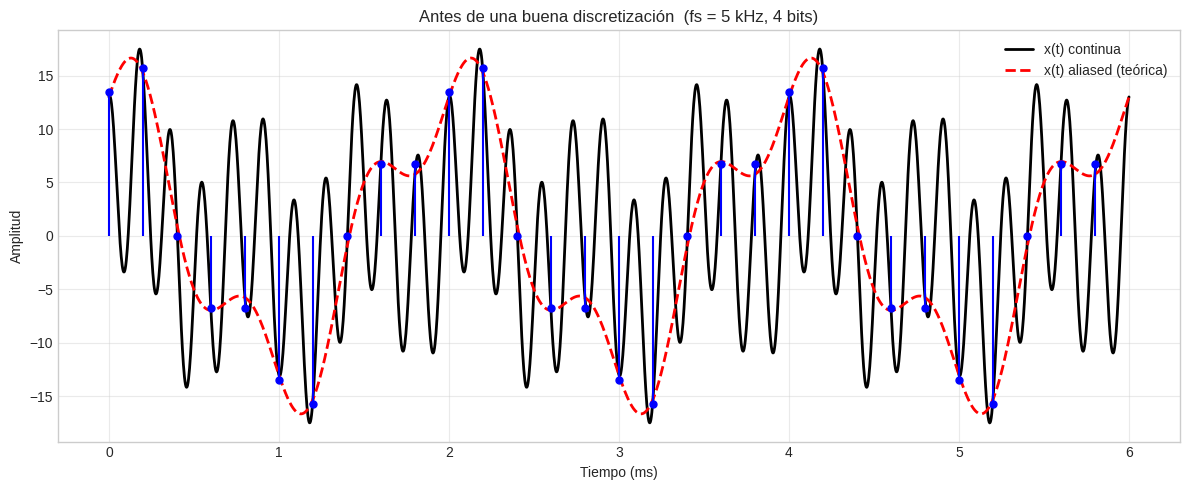

In [22]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Caso 1: fs = 5 kHz / 4 bits (inapropiado) ---
ax1.plot(t_cont*1e3, x_cont, 'k-', lw=2, label='x(t) continua')
ax1.plot(t_cont*1e3, x_aliased_cont(t_cont), 'r--', lw=2, label='x(t) aliased (teórica)')
m1, s1, b1 = ax1.stem(t_bad*1e3, xq_bad, linefmt='b-', markerfmt='bo', basefmt=' ')
plt.setp(m1, markersize=5)
ax1.set_title('Discretización INAPROPIADA  (fs = 5 kHz, 4 bits)')
ax1.set_ylabel('Amplitud')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.4)

# --- Caso 2: fs = 20 kHz / 8 bits (ADECUADO) ---
# (Solo pulsos de Dirac: sin señal de fondo, sin marcadores, sin línea base)
m2, s2, b2 = ax2.stem(t_good*1e3, xq_good, linefmt='g-', markerfmt=' ', basefmt=' ')
b2.set_visible(False)                 # oculta la línea base
plt.setp(s2, linewidth=1.2)           # grosor de los palitos
ax2.set_title('Discretización ADECUADA  (fs = 20 kHz, 8 bits)')
ax2.set_xlabel('Tiempo (ms)')
ax2.set_ylabel('Amplitud')
ax2.grid(True, alpha=0.4)

# --- Caso 2: fs = 20 kHz / 8 bits (adecuado) - Agregar señal continua para comparación ---
ax2.plot(t_cont*1e3, x_cont, 'k-', lw=2, label='x(t) continua')
ax2.legend(loc='upper right') # Add legend for the second plot


plt.tight_layout()
plt.show()

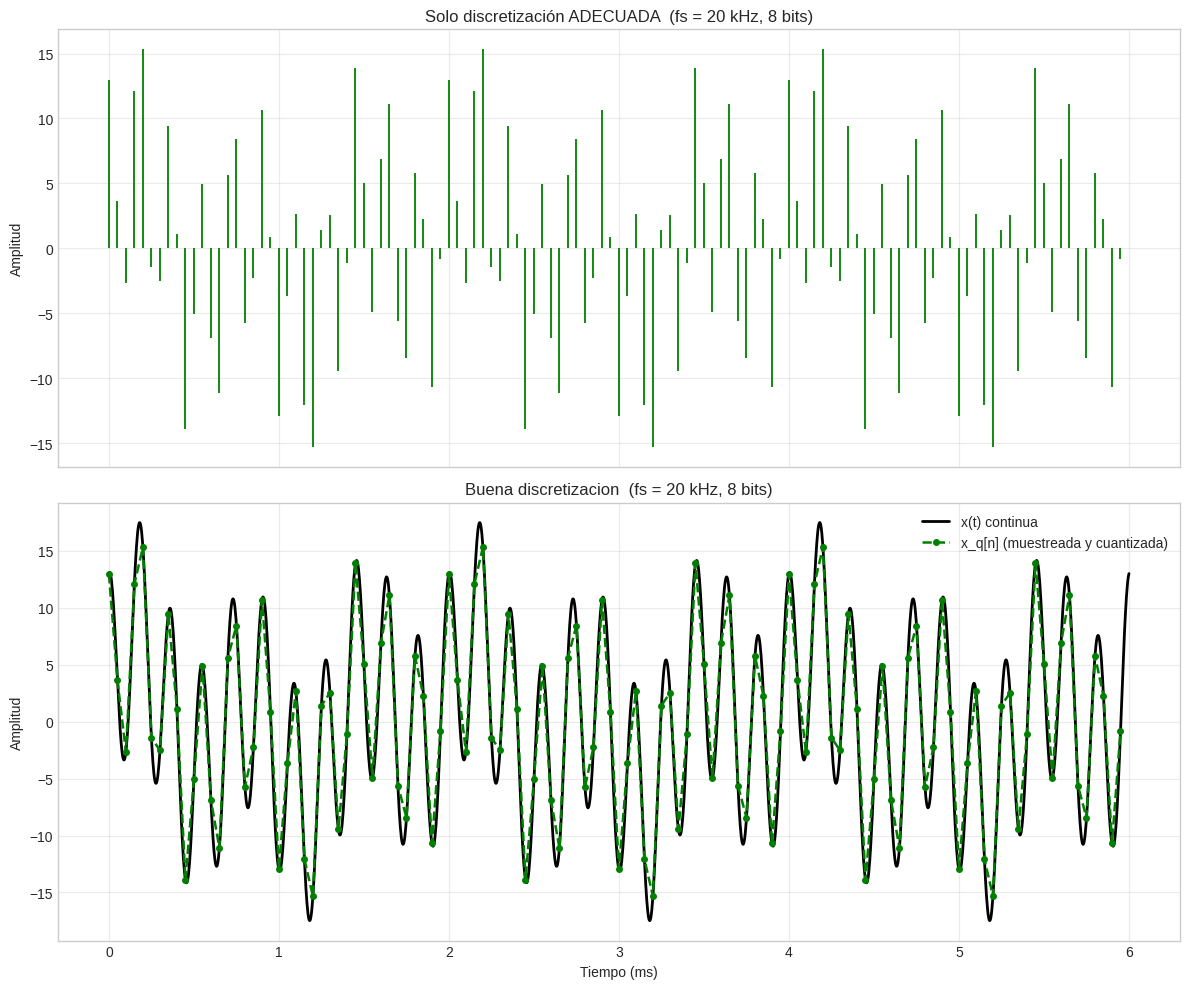

#Pregunta 4

##**Datos:**




Señal par y periódica de periodo $T$ con $\omega_0=\dfrac{2\pi}{T}$, vértices en $t\in\{0,\pm d_1,\pm d_2\}$ con $0<d_1<d_2<\tfrac{T}{2}$ y amplitud $A$.  
Por ser **par y real**: $C_{-n}=C_n\in\mathbb{R}$ y $\Im\{C_n\}=0$.


### 1) Segunda derivada como suma de deltas


$$
x''(t)=\underbrace{\frac{2A}{d_1}}_{\alpha_0}\,\delta(t)
+\underbrace{\Big(-\frac{A}{\,d_2-d_1\,}\Big)}_{\alpha_1}\,[\delta(t-d_1)+\delta(t+d_1)]
+\underbrace{\frac{A}{\,d_2-d_1\,}}_{\alpha_2}\,[\delta(t-d_2)+\delta(t+d_2)].
$$

### 2) Relación de coeficientes entre $x(t)$ y $x''(t)$


$$
x(t)=\sum_{n=-\infty}^{\infty}C_n e^{jn\omega_0 t}
\quad\Longrightarrow\quad
x''(t)=\sum_{n=-\infty}^{\infty}(jn\omega_0)^2 C_n e^{jn\omega_0 t}
=-\sum_{n=-\infty}^{\infty}n^2\omega_0^2\,C_n e^{jn\omega_0 t}.
$$
Por ortogonalidad:
$$
C_n''=\frac{1}{T}\int_{-T/2}^{T/2}x''(t)e^{-jn\omega_0 t}\,dt
=-\,n^2\omega_0^2\,C_n,\qquad n\neq 0.
$$



### 3) Cálculo de $C_n''$ (selectividad de $\delta$)


$$
\begin{aligned}
C_n''&=\frac{1}{T}\!\left[
\alpha_0
+2\alpha_1\cos(n\omega_0 d_1)
+2\alpha_2\cos(n\omega_0 d_2)
\right].
\end{aligned}
$$





### 4) Coeficientes de Fourier $C_n$ para $n\neq 0$


$$
\boxed{
C_n
=-\,\frac{1}{\,n^2\omega_0^2 T\,}\left[
\frac{2A}{d_1}
-\frac{2A}{\,d_2-d_1\,}\cos(n\omega_0 d_1)
+\frac{2A}{\,d_2-d_1\,}\cos(n\omega_0 d_2)
\right],\quad n\neq 0.
}
$$




### 5) Término DC


$$
\boxed{\,C_0=\frac{1}{T}\int_{-T/2}^{T/2}x(t)\,dt=\frac{A\,d_1}{T}\, }.
$$




### 6) Propiedades del espectro



$$
C_{-n}=C_n\in\mathbb{R},\qquad
|C_n|=|C_{-n}|,\qquad
\angle C_n=
\begin{cases}
0,& C_n>0,\\
\pi,& C_n<0.
\end{cases}
$$

##Simulacion Phyton

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML

# PARÁMETROS DE LA SEÑAL DE LA PREGUNTA 4

signal_amplitude = 25           # Amplitud máxima de la señal (altura de los picos)
signal_period = 1e-2         # Periodo de la señal (10 ms)
fundamental_freq = 1 / signal_period       # Frecuencia fundamental
sampling_freq = 2000 * fundamental_freq   # Frecuencia de muestreo (debe ser >> Fo para precisión)
time_vector = np.arange(-signal_period/2, signal_period/2, 1/sampling_freq)  # Vector de tiempo en un periodo

# Puntos intermedios dentro del periodo (definen los vértices del triángulo)
peak_point_1 = 0.001 # Define la posición del primer pico triangular
peak_point_2 = 0.002 # Define la posición del segundo pico triangular

# CONSTRUCCIÓN DE LA SEÑAL TRIANGULAR DOBLE PICO

# Inicializamos el vector de señal con ceros
triangular_signal = np.zeros_like(time_vector)

# Construimos la señal por tramos según la definición de la señal triangular de doble pico
# Entre -peak_point_2 y -peak_point_1: sube de 0 a signal_amplitude
# Entre -peak_point_1 y 0: baja de signal_amplitude a 0
# Entre 0 y peak_point_1: sube de 0 a signal_amplitude
# Entre peak_point_1 y peak_point_2: baja de signal_amplitude a 0
# Fuera de ese rango: vale 0
for i, t in enumerate(time_vector):
    if -peak_point_2 <= t < -peak_point_1:
        triangular_signal[i] = (signal_amplitude / (peak_point_2 - peak_point_1)) * (t + peak_point_2)             # tramo ascendente izquierdo
    elif -peak_point_1 <= t < 0:
        triangular_signal[i] = (-signal_amplitude / peak_point_1) * t                          # tramo descendente izquierdo
    elif 0 <= t < peak_point_1:
        triangular_signal[i] = (signal_amplitude / peak_point_1) * t                           # tramo ascendente derecho
    elif peak_point_1 <= t < peak_point_2:
        triangular_signal[i] = (-signal_amplitude / (peak_point_2 - peak_point_1)) * (t - peak_point_1) + signal_amplitude        # tramo descendente derecho
    else:
        triangular_signal[i] = 0                                      # fuera del rango: señal = 0

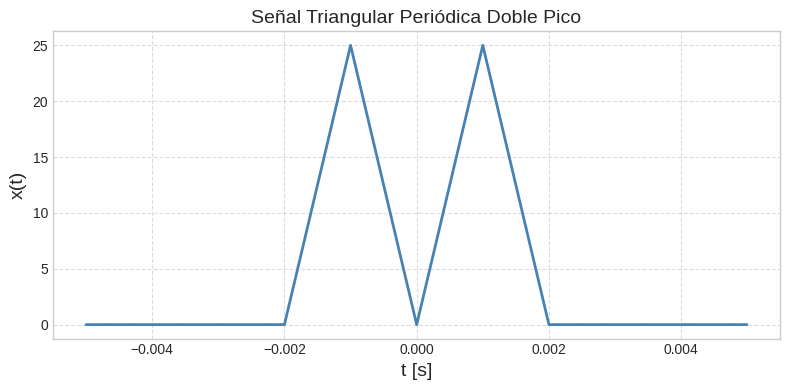

/tmp/ipython-input-784086754.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fourier_coeffs[n + num_harmonics] = (1 / signal_period) * np.trapz(triangular_signal * np.exp(-1j * n * fundamental_angular_freq * time_vector), time_vector) # Usamos variables renombradas


In [36]:
# GRAFICAMOS LA SEÑAL ORIGINAL

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_vector, triangular_signal, color='steelblue', linewidth=2) # Usamos las variables renombradas
ax.set_xlabel('t [s]', fontsize=14)
ax.set_ylabel('x(t)', fontsize=14)
ax.set_title('Señal Triangular Periódica Doble Pico', fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

# CÁLCULO DE LOS COEFICIENTES DE LA SERIE DE FOURIER

# Número de armónicos a considerar (positivo y negativo)
num_harmonics = 10 # Renombramos N a num_harmonics
fundamental_angular_freq = 2 * np.pi / signal_period  # Renombramos wo a fundamental_angular_freq

# Creamos las funciones base e^{j n w0 t} para cada armónico
fourier_basis_functions = np.zeros((len(time_vector), 2 * num_harmonics + 1), dtype=np.complex128) # Renombramos phin
harmonic_indices = np.linspace(-num_harmonics, num_harmonics, 2 * num_harmonics + 1) # Renombramos nv
for n in range(-num_harmonics, num_harmonics + 1):
    fourier_basis_functions[:, n + num_harmonics] = np.exp(1j * n * fundamental_angular_freq * time_vector) # Usamos variables renombradas

# Calculamos los coeficientes Cn mediante integración numérica
fourier_coeffs = np.zeros(2 * num_harmonics + 1, dtype=np.complex128) # Renombramos Cn
for n in range(-num_harmonics, num_harmonics + 1):
    fourier_coeffs[n + num_harmonics] = (1 / signal_period) * np.trapz(triangular_signal * np.exp(-1j * n * fundamental_angular_freq * time_vector), time_vector) # Usamos variables renombradas

# Vector de índices n para graficar (usamos harmonic_indices definido antes)
# nv = np.linspace(-N, N, 2 * N + 1) # Esta línea ya no es necesaria

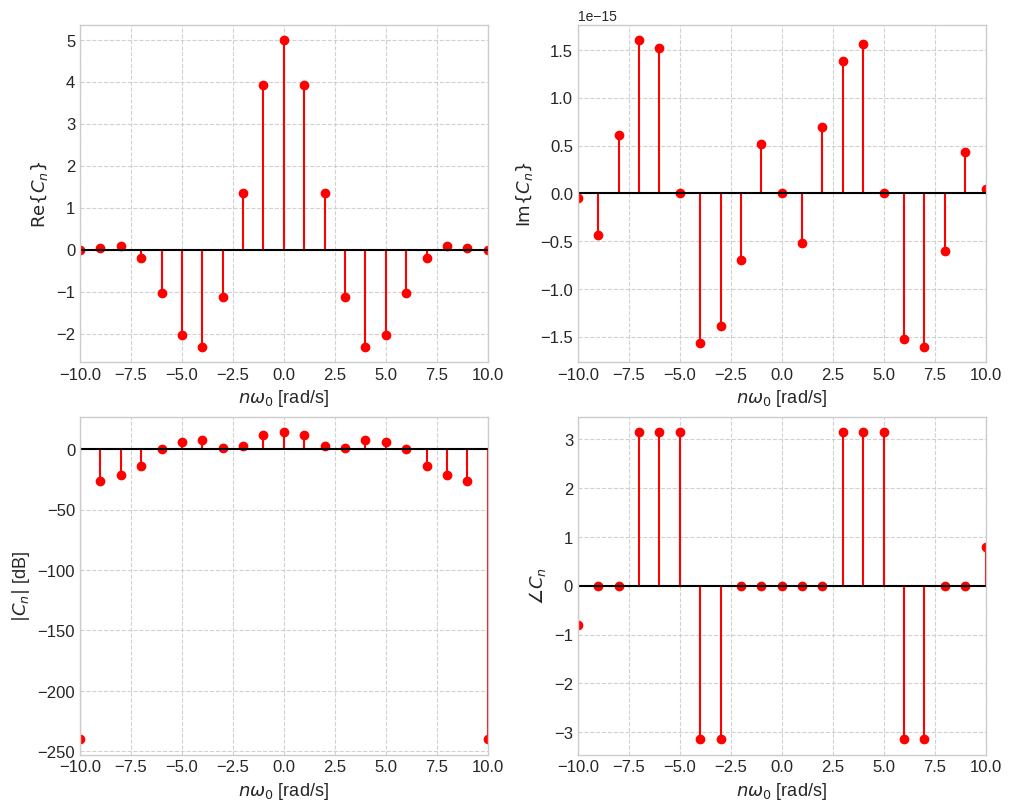

In [37]:
# VISUALIZACIÓN DEL ESPECTRO DE FOURIER

fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# Parte real de Cn
axs[0, 0].stem(harmonic_indices, np.real(fourier_coeffs), linefmt='r', markerfmt='ro', basefmt='k') # Usamos variables renombradas
axs[0, 0].set_xlabel(r'$n\omega_0$ [rad/s]', fontsize=13)
axs[0, 0].set_ylabel(r'$\mathrm{Re}\{C_n\}$', fontsize=13)
axs[0, 0].grid(True, linestyle='--', linewidth=0.8, alpha=0.9)

# Parte imaginaria de Cn
axs[0, 1].stem(harmonic_indices, np.imag(fourier_coeffs), linefmt='r', markerfmt='ro', basefmt='k') # Usamos variables renombradas
axs[0, 1].set_xlabel(r'$n\omega_0$ [rad/s]', fontsize=13)
axs[0, 1].set_ylabel(r'$\mathrm{Im}\{C_n\}$', fontsize=13)
axs[0, 1].grid(True, linestyle='--', linewidth=0.8, alpha=0.9)

# Magnitud en dB
axs[1, 0].stem(harmonic_indices, 20 * np.log10(np.abs(fourier_coeffs) + 1e-12), linefmt='r', markerfmt='ro', basefmt='k') # Usamos variables renombradas
axs[1, 0].set_xlabel(r'$n\omega_0$ [rad/s]', fontsize=13)
axs[1, 0].set_ylabel(r'$|C_n|$ [dB]', fontsize=13)
axs[1, 0].grid(True, linestyle='--', linewidth=0.8, alpha=0.9)

# Fase (ángulo de Cn)
axs[1, 1].stem(harmonic_indices, np.angle(fourier_coeffs), linefmt='r', markerfmt='ro', basefmt='k') # Usamos variables renombradas
axs[1, 1].set_xlabel(r'$n\omega_0$ [rad/s]', fontsize=13)
axs[1, 1].set_ylabel(r'$\angle C_n$', fontsize=13)
axs[1, 1].grid(True, linestyle='--', linewidth=0.8, alpha=0.9)

for ax in axs.flat:
    ax.tick_params(labelsize=12)
    ax.set_xlim([harmonic_indices[0], harmonic_indices[-1]]) # Usamos variables renombradas

plt.show()

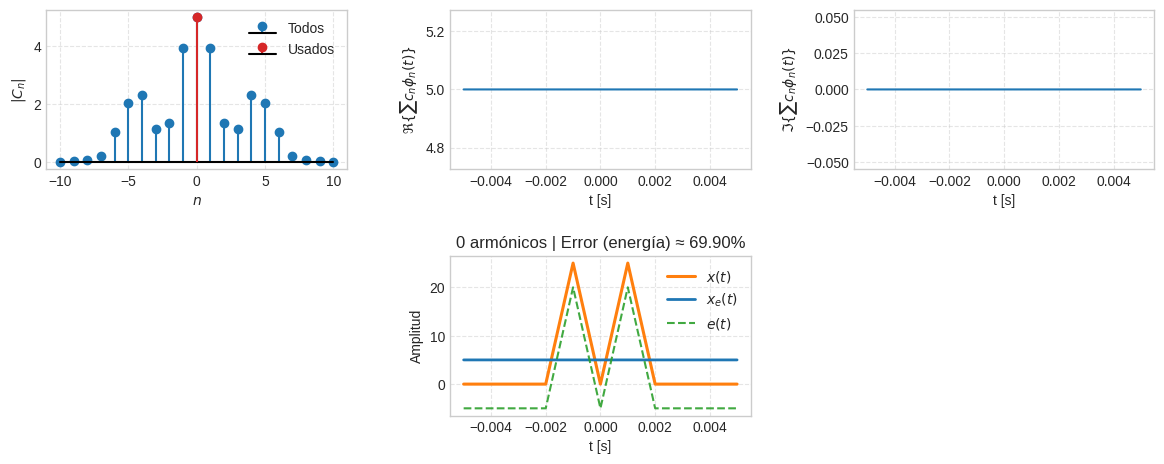

In [38]:
# ANIMACIÓN DE LA RECONSTRUCCIÓN CON LA SERIE DE FOURIER

# Potencia total de la señal (para calcular el error relativo)
total_power = np.sum(np.abs(fourier_coeffs) ** 2) # Renombramos Px y usamos fourier_coeffs

# Creamos la figura para animar
fig_anim, ax_anim = plt.subplots(2, 3, figsize=(12, 5)) # Renombramos fig y ax

def update_animation(n_used): # Renombramos update
    # Limpiamos todos los subgráficos
    for a in ax_anim.flat: # Usamos ax_anim
        a.clear()

    # Seleccionamos los armónicos activos (centrados en 0)
    lo = num_harmonics - n_used # Usamos num_harmonics
    hi = num_harmonics + n_used
    idx = np.arange(lo, hi+1)
    used_harmonic_indices = harmonic_indices[idx] # Renombramos nv_u y usamos harmonic_indices
    used_fourier_coeffs = fourier_coeffs[idx] # Renombramos Cn_u y usamos fourier_coeffs

    # Reconstrucción parcial
    reconstructed_signal = (fourier_basis_functions[:, idx] @ used_fourier_coeffs) # Renombramos xe y usamos variables renombradas
    spectral_components = fourier_basis_functions[:, idx] * used_fourier_coeffs         # Renombramos ce y usamos variables renombradas

    # Espectro con resaltado de armónicos usados
    ax_anim[0, 0].stem(harmonic_indices, np.abs(fourier_coeffs), basefmt='k', label='Todos') # Usamos variables renombradas
    ax_anim[0, 0].stem(used_harmonic_indices, np.abs(used_fourier_coeffs), basefmt='k', linefmt='C3-', markerfmt='C3o', label='Usados') # Usamos variables renombradas
    ax_anim[0, 0].set_xlabel(r'$n$'); ax_anim[0, 0].set_ylabel(r'$|C_n|$'); ax_anim[0, 0].legend()
    ax_anim[0, 0].grid(True, ls='--', alpha=0.5)

    # Suma real e imaginaria de las componentes usadas
    ax_anim[0, 1].plot(time_vector, np.real(spectral_components).sum(axis=1)) # Usamos variables renombradas
    ax_anim[0, 1].set_xlabel('t [s]'); ax_anim[0, 1].set_ylabel(r'$\Re\{\sum c_n \phi_n(t)\}$')
    ax_anim[0, 1].grid(True, ls='--', alpha=0.5)

    ax_anim[0, 2].plot(time_vector, np.imag(spectral_components).sum(axis=1)) # Usamos variables renombradas
    ax_anim[0, 2].set_xlabel('t [s]'); ax_anim[0, 2].set_ylabel(r'$\Im\{\sum c_n \phi_n(t)\}$')
    ax_anim[0, 2].grid(True, ls='--', alpha=0.5)


    # Señal original vs reconstruida y error en tiempo
    time_error = triangular_signal - np.real(reconstructed_signal) # Renombramos et y usamos variables renombradas
    used_energy = np.sum(np.abs(used_fourier_coeffs)**2) # Usamos variables renombradas
    relative_error = 1.0 - (used_energy / total_power) if total_power > 0 else 0.0 # Renombramos er y usamos variables renombradas

    ax_anim[1, 1].plot(time_vector, triangular_signal, 'C1', linewidth=2.2, label='$x(t)$') # Usamos variables renombradas
    ax_anim[1, 1].plot(time_vector, np.real(reconstructed_signal), 'C0', linewidth=2.0, label='$x_e(t)$') # Usamos variables renombradas
    ax_anim[1, 1].plot(time_vector, time_error, 'C2--', alpha=0.9, label='$e(t)$') # Usamos variables renombradas
    ax_anim[1, 1].set_title(f'{n_used} armónicos | Error (energía) ≈ {100*relative_error:.2f}%') # Usamos variables renombradas
    ax_anim[1, 1].set_xlabel('t [s]'); ax_anim[1, 1].set_ylabel('Amplitud')
    ax_anim[1, 1].legend(loc='upper right'); ax_anim[1, 1].grid(True, ls='--', alpha=0.5)

    # Paneles libres
    ax_anim[1, 0].axis('off'); ax_anim[1, 2].axis('off')
    fig_anim.tight_layout(pad=2.0)


anim = animation.FuncAnimation(fig_anim, update_animation, frames=np.arange(0, num_harmonics+1), interval=220, blit=False) # Usamos variables renombradas y fig_anim, update_animation

# If you're in Jupyter and want to see it inline, uncomment:
anim